In [28]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_cross_modality, evaluate_within_modality, evaluate_mixed_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from diagnostics import plot_diagnostics

In [29]:
base_dir = 'h5_sep'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]
font = '20F/A'
condition = 'Control' #put 'Parity' for parity, 'Control' for control

### Cross-modality

#### Digits → Number Words

In [30]:
dig_to_words = evaluate_cross_modality(base_dir, subjects, 'Dig', 'NumWo', font, condition)

#### Number Words → Digits

In [31]:
words_to_dig = evaluate_cross_modality(base_dir, subjects, 'NumWo', 'Dig', font, condition)

#### Plotting diagnostics


Digits→Words Performance:
Accuracy: 0.497 (Chance: 0.5)
Balanced Accuracy: 0.497
ROC AUC: 0.498
Matthews CC: -0.006
Support: 3220 samples


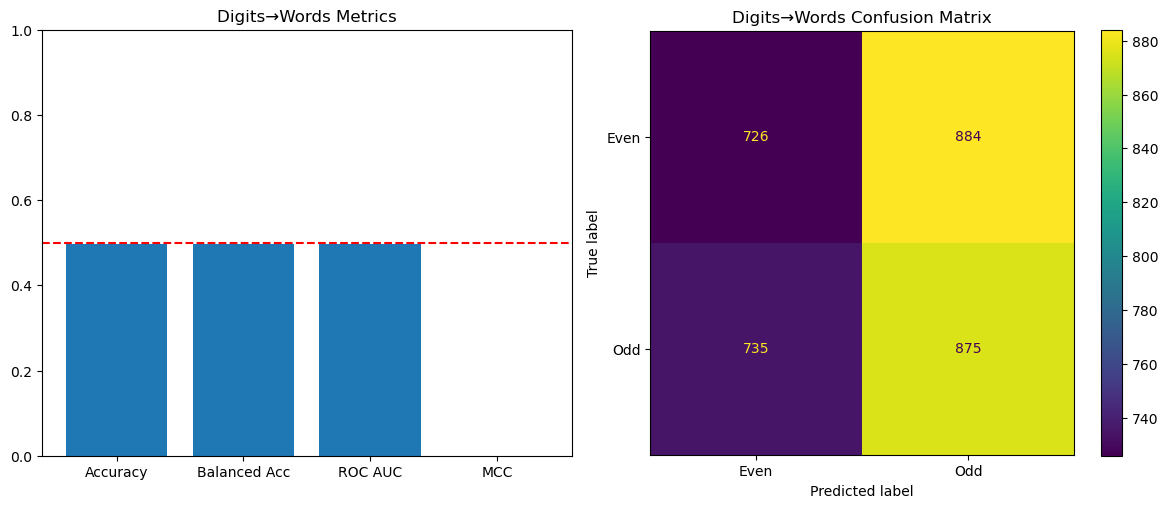

         feature  importance
7    homogeneity    0.106705
6  dissimilarity    0.106199
8         energy    0.095691
1          theta    0.095590
5       contrast    0.094410

Words→Digits Performance:
Accuracy: 0.493 (Chance: 0.5)
Balanced Accuracy: 0.493
ROC AUC: 0.498
Matthews CC: -0.014
Support: 3220 samples


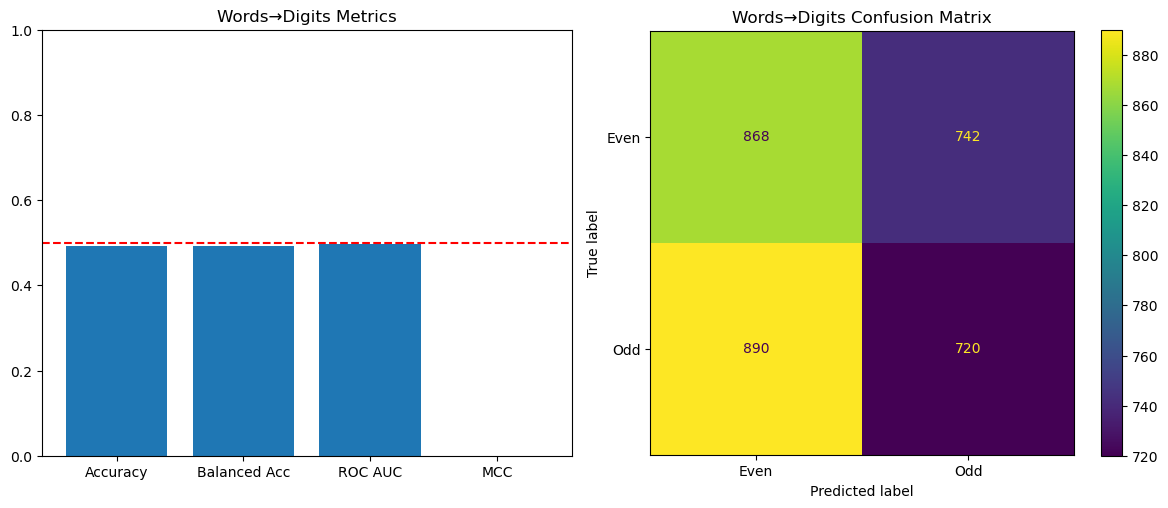

         feature  importance
7    homogeneity    0.108946
8         energy    0.107675
6  dissimilarity    0.103716
9    correlation    0.101831
1          theta    0.099789


In [32]:
for name, result in [('Digits→Words', dig_to_words), 
                    ('Words→Digits', words_to_dig)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null-model comparison

In [33]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

Dig null accuracy: 0.500
NumWo null accuracy: 0.500


### Within-modality

#### Digits

In [34]:
dig_results = evaluate_within_modality(base_dir, subjects, 'Dig', font, condition)

#### Number Words (Within Modality)

In [35]:
numwo_results = evaluate_within_modality(base_dir, subjects, 'NumWo', font, condition)

#### Plotting diagnostics


Digits Performance:
Accuracy: 0.934 (Chance: 0.5)
Balanced Accuracy: 0.934
ROC AUC: 0.984
Matthews CC: 0.867
Support: 3220 samples


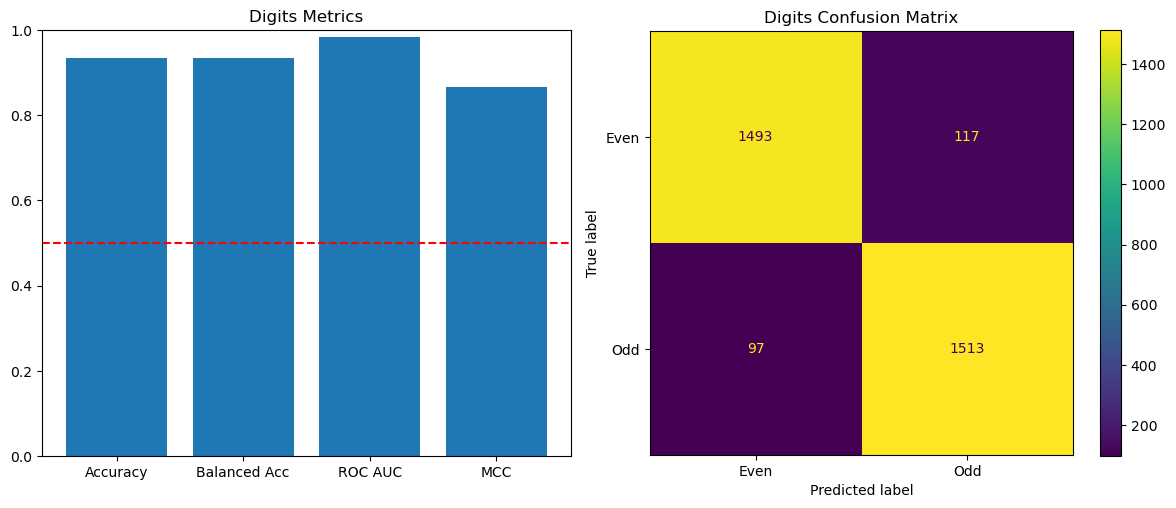

         feature  importance
7    homogeneity    0.106705
6  dissimilarity    0.106199
8         energy    0.095691
1          theta    0.095590
5       contrast    0.094410

Number Words Performance:
Accuracy: 0.938 (Chance: 0.5)
Balanced Accuracy: 0.938
ROC AUC: 0.988
Matthews CC: 0.876
Support: 3220 samples


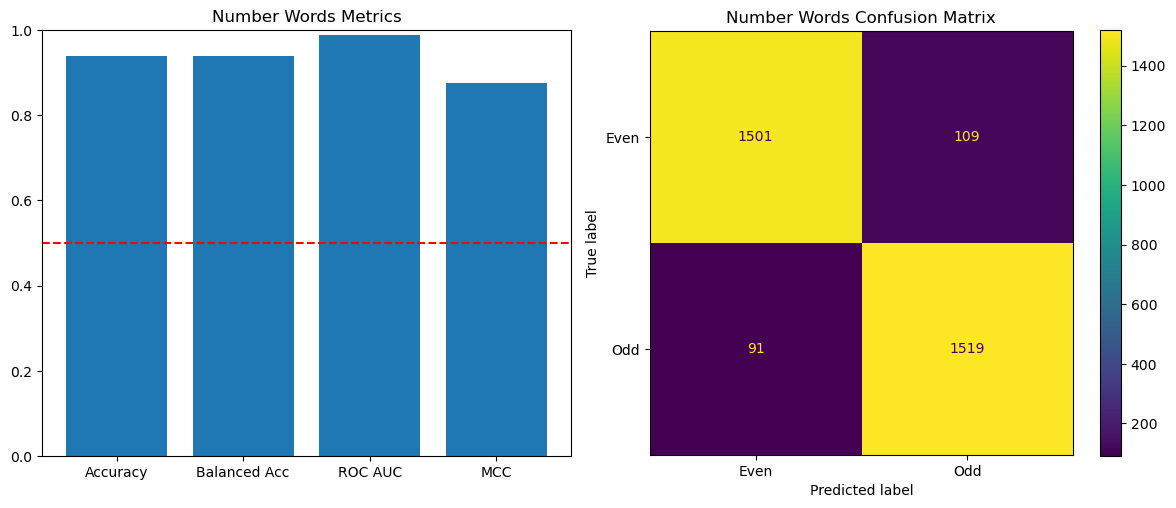

         feature  importance
7    homogeneity    0.108946
8         energy    0.107675
6  dissimilarity    0.103716
9    correlation    0.101831
1          theta    0.099789


In [36]:
for name, result in [('Digits', dig_results), 
                    ('Number Words', numwo_results)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null Model Comparison

In [24]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

Dig null accuracy: 0.500
NumWo null accuracy: 0.500


### Mixed modality

#### Mixed → Digits

In [37]:
mixed_to_digits = evaluate_mixed_modality(base_dir, subjects, 'Dig', font, condition)

#### Mixed → Number Words

In [38]:
mixed_to_words = evaluate_mixed_modality(base_dir, subjects, 'NumWo', font, condition)

#### Plotting diagnostics


Mixed→Digits Performance:
Accuracy: 0.878 (Chance: 0.5)
Balanced Accuracy: 0.878
ROC AUC: 0.954
Matthews CC: 0.755
Support: 3220 samples


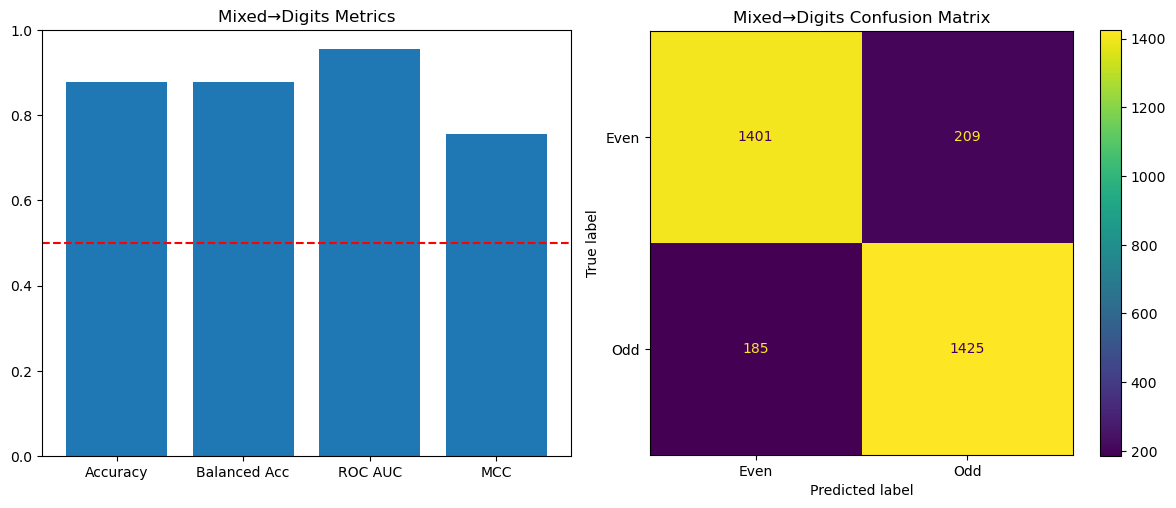

         feature  importance
4          gamma    0.101548
0          delta    0.094612
6  dissimilarity    0.094610
7    homogeneity    0.092791
8         energy    0.092077

Mixed→Words Performance:
Accuracy: 0.871 (Chance: 0.5)
Balanced Accuracy: 0.871
ROC AUC: 0.947
Matthews CC: 0.742
Support: 3220 samples


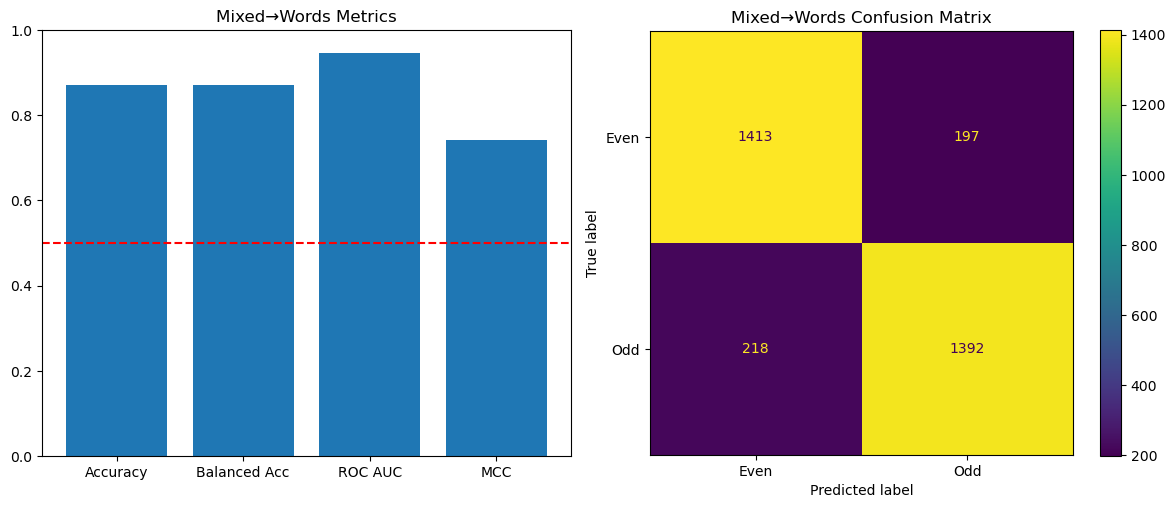

         feature  importance
4          gamma    0.101548
0          delta    0.094612
6  dissimilarity    0.094610
7    homogeneity    0.092791
8         energy    0.092077


In [39]:
for name, result in [('Mixed→Digits', mixed_to_digits), 
                    ('Mixed→Words', mixed_to_words)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")